In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
"""
Type 1 — Return abusers
         Buy products, return everything
         Monetary ≈ 0, Frequency > 1

Type 2 — Bulk buyers / resellers
         Order quantities 10-100x normal customers
         TotalItems and AvgItemsPerOrder extremely high

Type 3 — One-hit wonders
         Single enormous purchase, never seen again
         High Monetary, Frequency = 1, High Recency

Type 4 — Ghost customers
         Registered, minimal activity
         All metrics near zero

Type 5 — Erratic buyers
         Completely unpredictable pattern
         No consistent RFM profile
"""

'\nType 1 — Return abusers\n         Buy products, return everything\n         Monetary ≈ 0, Frequency > 1\n\nType 2 — Bulk buyers / resellers\n         Order quantities 10-100x normal customers\n         TotalItems and AvgItemsPerOrder extremely high\n\nType 3 — One-hit wonders\n         Single enormous purchase, never seen again\n         High Monetary, Frequency = 1, High Recency\n\nType 4 — Ghost customers\n         Registered, minimal activity\n         All metrics near zero\n\nType 5 — Erratic buyers\n         Completely unpredictable pattern\n         No consistent RFM profile\n'

In [3]:
df = pd.read_csv("rfm_scored.csv")

In [4]:
df.head()

,CustomerID,Recency,Frequency,Monetary,AvgOrderValue,TotalItems,DistinctProducts,TenureDays,AvgItemsPerOrder,is_suspicious,R_score,F_score,M_score,RFM_Score,RFM_Total,Segment
0,12347.0,2,7,4310.00,23.681319,2458,103,367,351.142857,0,5,4,5,545,14,Champion
1,12348.0,75,4,1797.24,57.975484,2341,22,358,585.250000,0,2,3,4,234,9,At Risk
2,12349.0,19,1,1757.55,24.076027,631,73,19,631.000000,0,4,1,4,414,9,Promising
3,12350.0,310,1,334.40,19.670588,197,17,310,197.000000,0,1,1,2,112,4,Lost Customers
4,12352.0,36,11,1545.41,16.267474,470,59,297,42.727273,0,3,5,4,354,12,Loyal Customer


In [5]:
feature_cols = [
    "Recency", "Frequency", "Monetary",
    "AvgOrderValue", "TotalItems", "DistinctProducts",
    "TenureDays", "AvgItemsPerOrder"
]

In [6]:
customer_ids = df["CustomerID"].values
X_raw = df[feature_cols].fillna(0).values.astype(np.float32)

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

In [12]:
import torch
from torch import nn

In [18]:
class AutoEncoder(nn.Module):
  def __init__(self, input_dim = 8, latent_dim = 2):
    super().__init__()
    self.encoder = nn.Sequential(
        nn.Linear(input_dim, 16),
        nn.ReLU(),
        nn.Linear(16, 8),
        nn.ReLU(),
        nn.Linear(8, latent_dim)
    )
    self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 16),
            nn.ReLU(),
            nn.Linear(16, input_dim)
    )
  def forward(self, x):
      return self.decoder(self.encoder(x))

  def encode(self, x):
      return self.encoder(x)

In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = AutoEncoder(input_dim = 8, latent_dim = 2).to(device)
model.load_state_dict(torch.load("best_autoencoder.pt", map_location = device))
model.eval()

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=8, bias=True)
    (3): ReLU()
    (4): Linear(in_features=8, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=8, bias=True)
    (1): ReLU()
    (2): Linear(in_features=8, out_features=16, bias=True)
    (3): ReLU()
    (4): Linear(in_features=16, out_features=8, bias=True)
  )
)

In [20]:
X_tensor = torch.tensor(X_scaled).to(device)

In [21]:
with torch.no_grad():
  X_reconstructed = model(X_tensor).cpu().numpy()

reconstruction_error = np.mean(
    (X_scaled - X_reconstructed) ** 2,
    axis = 1
)

In [23]:
print(f"Reconstruction Error Stats:")
print(f"  Min:    {reconstruction_error.min():.4f}")
print(f"  Mean:   {reconstruction_error.mean():.4f}")
print(f"  Median: {np.median(reconstruction_error):.4f}")
print(f"  Max:    {reconstruction_error.max():.4f}")
print(f"  Std:    {reconstruction_error.std():.4f}")

Reconstruction Error Stats:
  Min:    0.0003
  Mean:   0.0801
  Median: 0.0208
  Max:    19.4147
  Std:    0.4097


In [25]:
threshold_95 = np.percentile(reconstruction_error, 95)
threshold_99 = np.percentile(reconstruction_error, 99)

In [27]:
df["anomaly_score"] = reconstruction_error
df["is_anomaly"] = (reconstruction_error > threshold_95).astype(int)

In [30]:
df["anomaly_severity"] = "Normal"
df.loc[reconstruction_error > threshold_95, "anomaly_severity"] = "Suspicious"
df.loc[reconstruction_error > threshold_99, "anomaly_severity"] = "High Risk"

In [32]:
feature_errors = (X_scaled - X_reconstructed) ** 2
feature_error_df = pd.DataFrame(feature_errors, columns=feature_cols)
df["primary_anomaly_feature"] = feature_error_df.idxmax(axis=1)

In [33]:
def classify_anomaly(row):
  if row["anomaly_severity"] == "Normal":
      return "Normal"

  if row["Monetary"] == 0 or row["TotalItems"] == 0:
    return "Return Abuses"

  if row["AvgItemsPerOrder"] > df["AvgItemsPerOrder"].quantile(0.95):
    return "Bulk Buyer / Reseller"

  if row["Frequency"] == 1 and row["Monetary"] > df["Monetary"].quantile(0.90):
    return "One-Hit High Spender"

  if row["Recency"] > df["Recency"].quantile(0.95) and row["Frequency"] <= 2:
    return "Ghost Customer"

  return "Erratic Behavior"

df["anomaly_type"] = df.apply(classify_anomaly, axis = 1)

In [34]:
print("\nAnomaly Type Distribution:")
print(df[df["is_anomaly"] == 1]["anomaly_type"].value_counts())


Anomaly Type Distribution:
anomaly_type
Erratic Behavior         125
Bulk Buyer / Reseller     85
Ghost Customer             7
Return Abuses              2
Name: count, dtype: int64


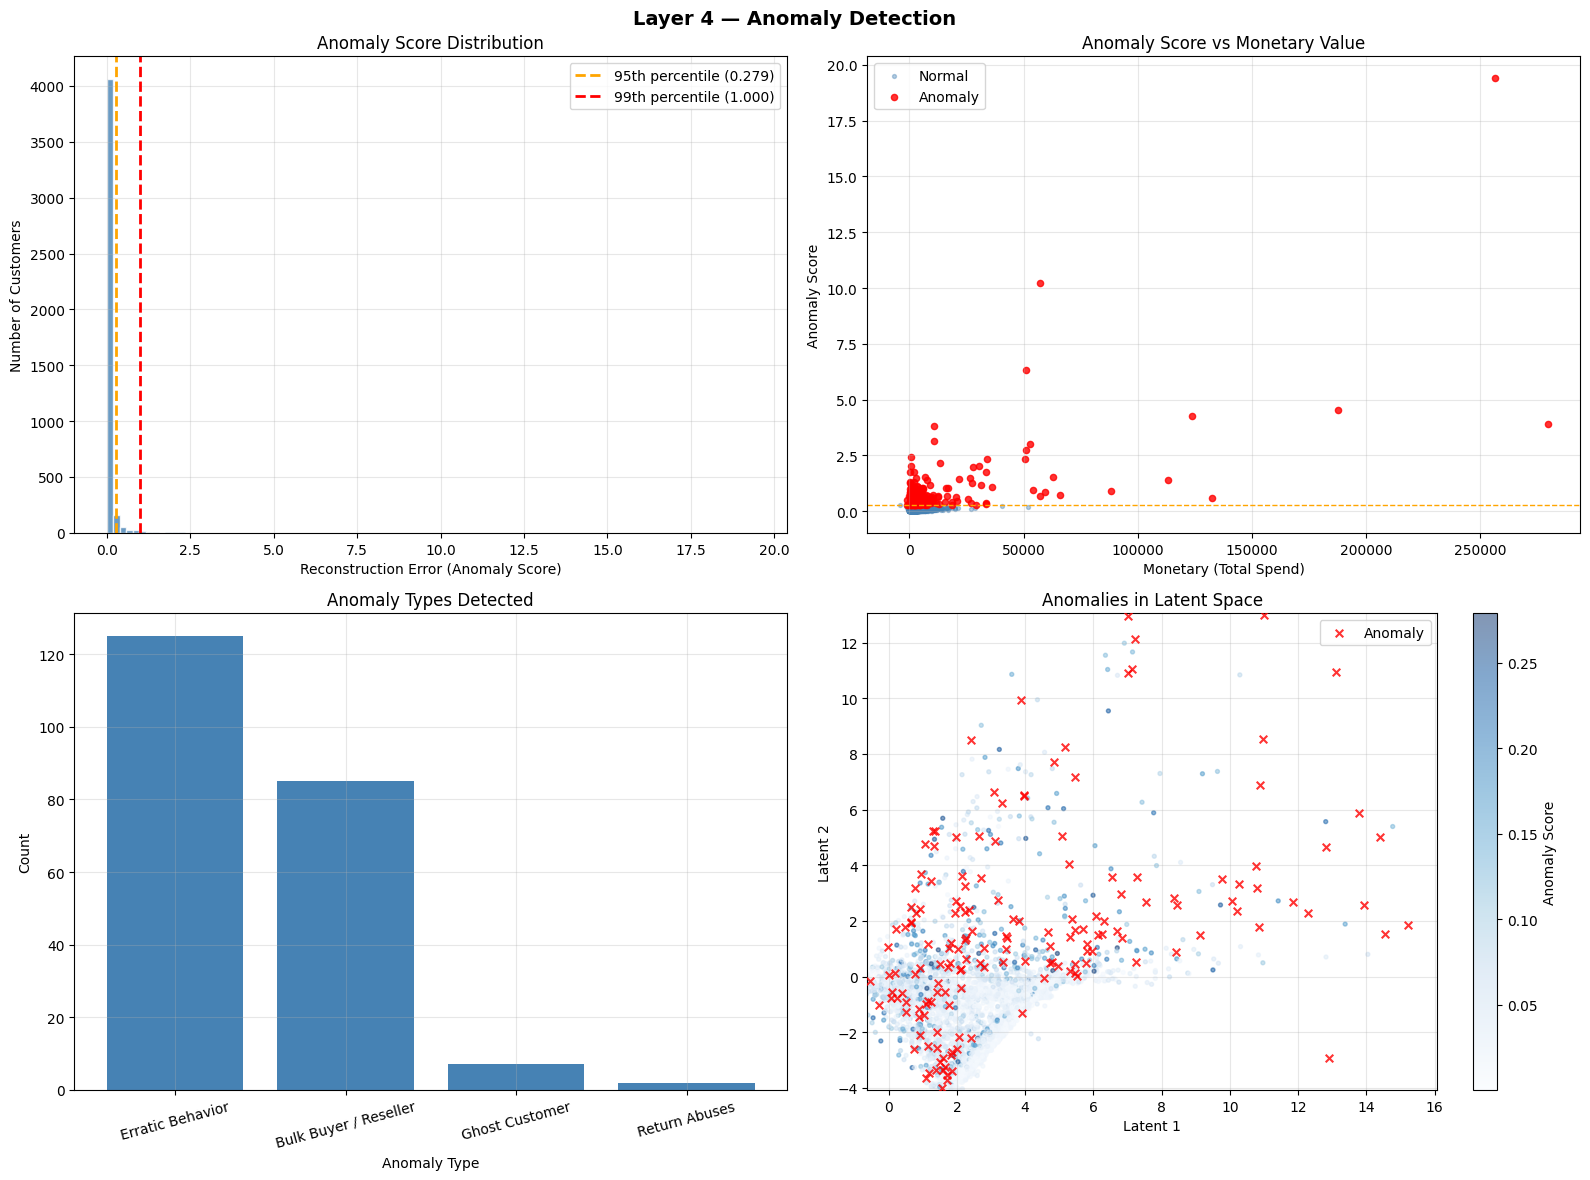

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1 — Reconstruction error distribution
axes[0][0].hist(
    reconstruction_error,
    bins=100,
    color="steelblue",
    edgecolor="white",
    alpha=0.8
)
axes[0][0].axvline(
    threshold_95, color="orange",
    linestyle="--", linewidth=2,
    label=f"95th percentile ({threshold_95:.3f})"
)
axes[0][0].axvline(
    threshold_99, color="red",
    linestyle="--", linewidth=2,
    label=f"99th percentile ({threshold_99:.3f})"
)
axes[0][0].set_xlabel("Reconstruction Error (Anomaly Score)")
axes[0][0].set_ylabel("Number of Customers")
axes[0][0].set_title("Anomaly Score Distribution")
axes[0][0].legend()
axes[0][0].grid(alpha=0.3)

# Plot 2 — Anomaly score vs Monetary
axes[0][1].scatter(
    df[df["is_anomaly"] == 0]["Monetary"],
    df[df["is_anomaly"] == 0]["anomaly_score"],
    s=8, alpha=0.4, color="steelblue", label="Normal"
)
axes[0][1].scatter(
    df[df["is_anomaly"] == 1]["Monetary"],
    df[df["is_anomaly"] == 1]["anomaly_score"],
    s=20, alpha=0.8, color="red", label="Anomaly"
)
axes[0][1].axhline(
    threshold_95, color="orange",
    linestyle="--", linewidth=1
)
axes[0][1].set_xlabel("Monetary (Total Spend)")
axes[0][1].set_ylabel("Anomaly Score")
axes[0][1].set_title("Anomaly Score vs Monetary Value")
axes[0][1].legend()
axes[0][1].grid(alpha=0.3)

# Plot 3 — Anomaly type breakdown
anomaly_counts = df[df["is_anomaly"] == 1]["anomaly_type"].value_counts()
axes[1][0].bar(
    anomaly_counts.index,
    anomaly_counts.values,
    color="steelblue"
)
axes[1][0].set_xlabel("Anomaly Type")
axes[1][0].set_ylabel("Count")
axes[1][0].set_title("Anomaly Types Detected")
axes[1][0].tick_params(axis="x", rotation=15)
axes[1][0].grid(alpha=0.3)

# Plot 4 — Anomaly score in latent space
with torch.no_grad():
    X_encoded = model.encode(X_tensor).cpu().numpy()

# Clip for visualization
x1, x2 = np.percentile(X_encoded[:, 0], [1, 99])
y1, y2 = np.percentile(X_encoded[:, 1], [1, 99])

normal_mask  = df["is_anomaly"] == 0
anomaly_mask = df["is_anomaly"] == 1

scatter = axes[1][1].scatter(
    X_encoded[normal_mask, 0],
    X_encoded[normal_mask, 1],
    c=reconstruction_error[normal_mask],
    s=8, alpha=0.5, cmap="Blues"
)
axes[1][1].scatter(
    X_encoded[anomaly_mask, 0],
    X_encoded[anomaly_mask, 1],
    c="red", s=30, alpha=0.8,
    marker="x", label="Anomaly", zorder=5
)
plt.colorbar(scatter, ax=axes[1][1], label="Anomaly Score")
axes[1][1].set_xlim(x1, x2)
axes[1][1].set_ylim(y1, y2)
axes[1][1].set_xlabel("Latent 1")
axes[1][1].set_ylabel("Latent 2")
axes[1][1].set_title("Anomalies in Latent Space")
axes[1][1].legend()
axes[1][1].grid(alpha=0.3)

plt.suptitle("Layer 4 — Anomaly Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("anomaly_detection.png", dpi=150)
plt.show()

In [37]:
print("\nTop 15 Most Anomalous Customers:")
anomaly_report = df[df["is_anomaly"] == 1].nlargest(15, "anomaly_score")[
    ["CustomerID", "Recency", "Frequency", "Monetary",
     "AvgItemsPerOrder", "anomaly_score",
     "anomaly_severity", "anomaly_type", "primary_anomaly_feature"]
].round(3)
print(anomaly_report.to_string())


Top 15 Most Anomalous Customers:
      CustomerID  Recency  Frequency   Monetary  AvgItemsPerOrder  anomaly_score anomaly_severity           anomaly_type primary_anomaly_feature
4221     18102.0        1         62  256438.49          1034.226      19.415001        High Risk  Bulk Buyer / Reseller                Monetary
1292     14096.0        4         34   57120.91           480.441      10.224000        High Risk       Erratic Behavior        DistinctProducts
1439     14298.0        3         45   50862.44          1289.356       6.322000        High Risk  Bulk Buyer / Reseller               Frequency
3746     17450.0        8         55  187482.17          1255.073       4.540000        High Risk  Bulk Buyer / Reseller              TotalItems
54       12415.0       24         26  123725.45          2970.846       4.267000        High Risk  Bulk Buyer / Reseller        AvgItemsPerOrder
1694     14646.0        2         77  279489.02          2554.792       3.893000        High Ris

In [38]:
df.to_csv("rfm_anomaly_scored.csv", index=False)
print(f"\nTotal anomalies flagged: {df['is_anomaly'].sum()}")
print(f"  Suspicious:  {(df['anomaly_severity'] == 'Suspicious').sum()}")
print(f"  High Risk:   {(df['anomaly_severity'] == 'High Risk').sum()}")
print("Saved: rfm_anomaly_scored.csv")


Total anomalies flagged: 219
  Suspicious:  175
  High Risk:   44
Saved: rfm_anomaly_scored.csv


In [40]:
most_anomalous = df.nlargest(1, "anomaly_score")[
    ["CustomerID", "Recency", "Frequency", "Monetary",
     "AvgItemsPerOrder", "TotalItems", "anomaly_score", "anomaly_type"]
]
print(most_anomalous.to_string())

      CustomerID  Recency  Frequency   Monetary  AvgItemsPerOrder  TotalItems  anomaly_score           anomaly_type
4221     18102.0        1         62  256438.49       1034.225806       64122       19.41473  Bulk Buyer / Reseller


In [41]:
bulk_buyers = df[df["anomaly_type"] == "Bulk Buyer / Reseller"].sort_values(
    "anomaly_score", ascending=False
)[["CustomerID", "Recency", "Frequency", "Monetary",
   "AvgItemsPerOrder", "TotalItems", "anomaly_score"]].head(10)

print(bulk_buyers.to_string())

      CustomerID  Recency  Frequency   Monetary  AvgItemsPerOrder  TotalItems  anomaly_score
4221     18102.0        1         62  256438.49       1034.225806       64122      19.414730
1439     14298.0        3         45   50862.44       1289.355556       58021       6.322414
3746     17450.0        8         55  187482.17       1255.072727       69029       4.539685
54       12415.0       24         26  123725.45       2970.846154       77242       4.266918
1694     14646.0        2         77  279489.02       2554.792208      196719       3.892941
1785     14769.0        3         10   10641.60        740.600000        7406       3.838850
4113     17949.0        1         52   52750.84        530.211538       27571       3.012741
1287     14088.0       10         14   50415.49        899.500000       12593       2.323227
70       12433.0        1          7   13375.87       1581.571429       11071       2.172244
3710     17404.0        4         18   30300.82       1795.777778     

In [42]:
"""
The autoencoder-based anomaly detection identified 219 anomalous customers (5% of the dataset)
using reconstruction error as an anomaly score. The model, trained on normal customer behavioral patterns,
struggles to reconstruct customers who deviate significantly from typical RFM profiles.
This produces high reconstruction error for genuinely unusual customers. The system automatically classifies anomalies into
four business-meaningful types: Erratic Behavior (125), Bulk Buyers/Resellers (85), Ghost Customers (7), and Return Abusers (2).
The most anomalous customer showed a reconstruction error of 19.4 — 97x the median — corresponding to £250,000 in total spend,
strongly suggesting a wholesale account being processed through the retail system.
"""

'\nThe autoencoder-based anomaly detection identified 219 anomalous customers (5% of the dataset) \nusing reconstruction error as an anomaly score. The model, trained on normal customer behavioral patterns, \nstruggles to reconstruct customers who deviate significantly from typical RFM profiles. \nThis produces high reconstruction error for genuinely unusual customers. The system automatically classifies anomalies into \nfour business-meaningful types: Erratic Behavior (125), Bulk Buyers/Resellers (85), Ghost Customers (7), and Return Abusers (2). \nThe most anomalous customer showed a reconstruction error of 19.4 — 97x the median — corresponding to £250,000 in total spend, \nstrongly suggesting a wholesale account being processed through the retail system.\n'